## Entrega 2 — Comparación de Familias y Validación
## Sistema de Recomendación de Películas: MovieLens 100K

**Institución:** EAFIT  
**Curso:** Aprendizaje de Máquina Aplicado  
**Profesor:** Marco Teran  
**Fecha límite:** 14/05/2026  
**Dataset:** MovieLens 100K — GroupLens Research
**Integrantes:** 
  - Jerónimo Pérez Baquero (jperezb5@eafit.edu.co)
  - David Grisales Posada (dgrisalesp@eafit.edu.co)
  - Esteban Vergara Giraldo (evergarag@eafit.edu.co)

---

### Preguntas centrales
- ¿Es posible predecir el rating (1–5) que un usuario le daría a una película que no ha visto?
- ¿Cuál de las siguientes tres familias de modelos que veremos es la más efectiva para este problema?
  - KNN (K nearest neighbors): Es el "caja negra" que encuentra patrones ocultos en las calificaciones, pero no sabe qué es una película de acción o quién es un técnico de 24 años.
  - SVD (singular value decomposition): Es el modelo "social". Busca personas similares a ti. Es muy fácil de explicar ("Te recomendamos esto porque a tu vecino le gustó").
  - Lasso y Ridge (linear regressions): Son los modelos  "basado en contenido". Aquí es donde le sacamos jugo a los archivos Users y Movies, con toda la data que venía en ellos.

### Importación de librerías y configuración

In [1]:
import warnings

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Configuration
warnings.filterwarnings("ignore")
np.random.seed(42)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid", palette="muted")

print("Libraries loaded successfully ✓")

Libraries loaded successfully ✓


In [2]:
# Path to raw data
DATA_PATH = "../data/raw/ml-100k/"

# Ratings
ratings = pd.read_csv(
    DATA_PATH + "u.data", sep="\t", names=["user_id", "item_id", "rating", "timestamp"]
)

# Users
users = pd.read_csv(
    DATA_PATH + "u.user",
    sep="|",
    names=["user_id", "age", "gender", "occupation", "zip_code"],
)

# Movies
movie_cols = [
    "item_id",
    "title",
    "release_date",
    "video_release_date",
    "imdb_url",
    "unknown",
    "Action",
    "Adventure",
    "Animation",
    "Children",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western",
]

movies = pd.read_csv(
    DATA_PATH + "u.item", sep="|", encoding="latin-1", names=movie_cols
)

print(f"Ratings:  {ratings.shape[0]:,} rows × {ratings.shape[1]} columns")
print(f"Users:    {users.shape[0]:,} rows × {users.shape[1]} columns")
print(f"Movies:   {movies.shape[0]:,} rows × {movies.shape[1]} columns")

Ratings:  100,000 rows × 4 columns
Users:    943 rows × 5 columns
Movies:   1,682 rows × 24 columns


In [3]:
ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [4]:
users.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [5]:
movies.head()

,item_id,title,release_date,video_release_date,imdb_url,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


## Conocimientos previos (gracias al EDA de la entrega 1)

### Calidad de datos (nulos, duplicados)

- **Ratings**: sin nulos, sin duplicados, rango válido (1–5). ✓
- **Users**: sin nulos en ninguna columna. ✓
- **Movies**:
  - `video_release_date`: 1,682/1,682 nulos
  - `release_date`: 1 nulo

Entendido. He ajustado el formato para que cada punto tenga la estructura de **Subtítulo: Texto**, manteniendo la decoración de Markdown para facilitar la lectura:

### Distribución de datos

- **Sesgo de positividad en Ratings:** Los ratings muestran sesgo de positividad — la media (~3.5) está por encima del punto medio de la escala (3.0). Ratings 3 y 4 concentran la mayoría de las interacciones. Esto implica que un baseline de media global ya captura parte del patrón.
- **Sparsity y el fenómeno de "Cola Larga":** La matriz usuario–película tiene una sparsity del 93.70% — solo 100,000 de 1,586,126 combinaciones posibles tienen rating. Ambas distribuciones muestran cola larga: pocos usuarios y pocas películas concentran la mayoría de interacciones. Esto introduce el problema de **cold start**: el modelo tendrá menor precisión para usuarios con pocas calificaciones y películas poco vistas.
- **Perfil demográfico y representatividad:** El perfil demográfico muestra sesgo significativo — aproximadamente 3 de cada 4 usuarios son hombres, la ocupación más frecuente es estudiante, y aunque el rango de edad es amplio (7–73 años), la mediana es 31. La media (34.1) está jalada por usuarios mayores. El modelo aprenderá principalmente de las preferencias de hombres jóvenes, lo que limita su generalización a otros perfiles demográficos.
- **Preferencia generacional:** El dataset refleja una preferencia generacional: la mayoría de los ratings se concentran en estrenos de los años 90. Dado que el perfil predominante es el de estudiantes jóvenes, existe una correlación clara entre la juventud del público y el consumo de cine reciente. Esto demuestra que, para este grupo, la relevancia de una película está fuertemente ligada a su fecha de lanzamiento.
- **Tendencia vs. Aclamación:** Existe una distinción clara entre lo que es tendencia y lo que es aclamado. Aunque los usuarios muestran una inclinación natural hacia el cine reciente, los datos confirman que la calidad no tiene fecha de caducidad. Películas con menor frecuencia de voto, pero mayor antigüedad, mantienen promedios superiores, lo que sugiere que el público sigue otorgando un valor especial a los clásicos que han logrado trascender su época.
- **Volumen histórico:** La base de datos refleja un boom del cine en los años 90's, ya que allí se concentra la mayor parte de la información sobre películas.
- **Recepción y Nichos de Mercado:** Se observa que la abundancia de lanzamientos no garantiza la mejor recepción. Aunque el cine de la época apostaba masivamente por el drama y la comedia, los usuarios mostraron un mayor aprecio por categorías con menor volumen de producción. Esto sugiere que los géneros minoritarios cuentan con un público más fiel y entusiasta, cuya valoración positiva compensa la falta de cantidad, demostrando que el interés de los usuarios es más profundo en secciones específicas de la industria que en el contenido de consumo masivo.

## Baseline

Este **Baseline** actúa como el umbral mínimo de éxito: cualquier modelo que pretenda solucionar el problema de recomendación debe ser significativamente más preciso que este cálculo básico (calculado en el primer notebook).

- **Definición del modelo:** Hemos definido el Baseline de manera puramente estadística como el **promedio global de las reseñas**. Matemáticamente, esto significa predecir siempre el mismo valor para cualquier combinación de usuario y película:

$$\hat{y}_i = \bar{y} = 3.53$$


- **Origen de los datos:** Siguiendo la exploración detallada en nuestro **primer notebook**, sabemos que el dataset presenta un marcado sesgo de positividad. El valor de $3.53$ (obtenido del promedio del conjunto de entrenamiento) ya captura esta tendencia central del comportamiento de los usuarios en MovieLens 100k.
- **Justificación:** El uso de una media global es un estándar en la industria. Si un modelo sofisticado (como SVD o Lasso) no logra reducir el error respecto a este promedio constante, significa que no está capturando patrones útiles de los datos o que el ruido es demasiado alto. En resumen: si no es mejor que el promedio, el modelo no es útil.
- **Métricas a superar:** Basándonos en los cálculos realizados anteriormente sobre el conjunto de prueba, nuestro objetivo en este notebook es superar el desempeño de esta línea base. Cualquier mejora en el **RMSE** o **MAE** respecto a estos valores será el indicador real de que nuestros modelos están aprendiendo relaciones valiosas entre los metadatos y las preferencias de los usuarios.
  - **RMSE = 1.1253:** En promedio, las predicciones del baseline se desvían del rating real en ±1.13 puntos en la escala 1–5. Esto significa que si el usuario califica una película con 4 estrellas, el baseline (que siempre predice 3.53) errará en aproximadamente 1.13 puntos de media.
  - **MAE = 0.9008:** El error promedio sin considerar dirección es de 0.90 puntos. Este valor más bajo que RMSE indica que hay pocas predicciones extremadamente erróneas — la mayoría de errores se concentra en una banda moderada alrededor de la media.


## Preprocesamiento y limpieza de datos

Tras analizar la naturaleza de los datos y los requerimientos de los modelos seleccionados (SVD, KNN, Lasso y Ridge), se han tomado las siguientes decisiones estratégicas:

### 1. Limpieza y Selección de Características (Feature Selection)

- **Ratings y Users:** No presentan valores nulos ni problemas de integridad, por lo que se mantienen en su estado original.
- **Movies:**
- **Eliminación de ruido:** Se descartan `video_release_date` (100% de valores nulos) e `imdb_url` y `title`, ya que no poseen valor predictivo para los modelos lineales o matriciales.
- **Ingeniería de variables:** De la columna `release_date` se extraerá únicamente el **año**, tratándolo como una variable numérica para capturar tendencias temporales (ej. películas clásicas vs. modernas). Los registros nulos en esta columna (mínimos) se imputarán con la mediana.
- **Géneros:** Se conservan las 19 columnas de género (Action, Sci-Fi, etc.) que ya vienen pre-codificadas como variables binarias (0 y 1).

### 2. Transformación de Datos (Encoding y Scaling)

Para los modelos de regresión (Lasso y Ridge), aplicaremos un tratamiento diferenciado mediante un `ColumnTransformer`:

- **Variables Categóricas (`gender`, `occupation`):** Se aplicará **One-Hot Encoding**. Esto transforma categorías de texto en columnas binarias independientes, evitando que el modelo asuma un orden jerárquico inexistente (como pensar que un "técnico" es mayor que un "escritor").
- **Estandarización (Z-Scaling):** Se aplicará `StandardScaler` **únicamente a las variables numéricas continuas** (edad y año de lanzamiento). Esto asegura que Lasso no penalice más a una variable solo por tener una escala mayor (ej. la edad de 50 vs. el género de 1).
- **Regla de Oro para Binarios:** Las variables resultantes del One-Hot Encoding y los géneros de las películas **no se estandarizan**. Se mantendrán como valores puros de 0 y 1 para preservar su significado matemático de "activación" dentro del modelo Lasso.

### 3. Estrategia de Validación y Prevención de Fuga (Data Leakage)

- **División de Datos:** Utilizaremos una partición de **60% Entrenamiento, 20% Validación y 20% Testeo**. Dado que las distribuciones de ratings por usuario no son uniformes, esta proporción nos permite tener un set de validación robusto para el ajuste de hiperparámetros ($\alpha$ en Lasso/Ridge) y un set de testeo representativo para el veredicto final.
- **Integridad del Escalador:** Para evitar el *data leakage*, el escalador (`StandardScaler`) se ajustará (`fit`) **exclusivamente con los datos de entrenamiento**. Posteriormente, esa misma transformación se aplicará (`transform`) a los sets de validación y testeo. Esto garantiza que el modelo no tenga información previa sobre la distribución o el rango de los datos que usaremos para evaluarlo.

In [6]:
# Drop columns with no predictive value
movies.drop(columns=["video_release_date", "imdb_url"], inplace=True)

In [7]:
print(f"Movies columns after cleaning: {movies.shape[1]}")
print(movies.columns.tolist())

Movies columns after cleaning: 22
['item_id', 'title', 'release_date', 'unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [8]:
# Extract release year from release_date
movies["release_year"] = pd.to_datetime(movies["release_date"], errors="coerce").dt.year

# Check the result
print(movies[["title", "release_date", "release_year"]].head(10))
print(f"\nNulls in release_year: {movies['release_year'].isnull().sum()}")
print(
    f"Year range: {movies['release_year'].min():.0f} – {movies['release_year'].max():.0f}"
)

                                               title release_date  \
0                                   Toy Story (1995)  01-Jan-1995   
1                                   GoldenEye (1995)  01-Jan-1995   
2                                  Four Rooms (1995)  01-Jan-1995   
3                                  Get Shorty (1995)  01-Jan-1995   
4                                     Copycat (1995)  01-Jan-1995   
5  Shanghai Triad (Yao a yao yao dao waipo qiao) ...  01-Jan-1995   
6                              Twelve Monkeys (1995)  01-Jan-1995   
7                                        Babe (1995)  01-Jan-1995   
8                            Dead Man Walking (1995)  01-Jan-1995   
9                                 Richard III (1995)  22-Jan-1996   

   release_year  
0        1995.0  
1        1995.0  
2        1995.0  
3        1995.0  
4        1995.0  
5        1995.0  
6        1995.0  
7        1995.0  
8        1995.0  
9        1996.0  

Nulls in release_year: 1
Year range: 1922

In [9]:
# Fill the single null with the median year
median_year = movies["release_year"].median()
movies["release_year"] = movies["release_year"].fillna(median_year)

print(f"Null filled with median year: {median_year:.0f}")
print(f"Nulls remaining: {movies['release_year'].isnull().sum()}")

Null filled with median year: 1995
Nulls remaining: 0


---

## Baseline Model Implementation

**Objetivo:** Establecer una línea base simple contra la cual comparar modelos más sofisticados.

**Definición:** Predecir siempre el rating global promedio: $\hat{y}_i = \bar{y} = 3.53$

**Justificación:** Este baseline captura la tendencia global del dataset (sesgo de positividad) y requiere 
solo una estadística. Es un estándar en sistemas de recomendación — cualquier modelo entrenado debe 
superar este simple promedio para considerarse útil.

In [10]:
# Prepare data for baseline

# If ratings data is not loaded, create sample data for demonstration
if "ratings" not in locals():
    print("Note: Creating sample data for baseline demonstration...")
    ratings = pd.DataFrame(
        {
            "user_id": np.repeat(np.arange(1, 944), 106)[:100000],
            "item_id": np.tile(np.arange(1, 1683), 60)[:100000],
            "rating": np.random.randint(1, 6, 100000),
        }
    )
    print("Sample data created with 100,000 ratings")

# Extract features (X) and target (y)
X = ratings[["user_id", "item_id"]].values
y = ratings["rating"].values

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {len(y_train):,} ratings")
print(f"Test set size:     {len(y_test):,} ratings")
print(f"\nTrain mean rating: {y_train.mean():.4f}")
print(f"Test mean rating:  {y_test.mean():.4f}")

Training set size: 80,000 ratings
Test set size:     20,000 ratings

Train mean rating: 3.5313
Test mean rating:  3.5242


In [11]:
# Baseline model: predict global mean for all test samples

# Calculate global mean from training data
global_mean = y_train.mean()

# Make predictions: always predict the global mean
y_baseline_pred = np.full(len(y_test), global_mean)

# Calculate metrics
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_baseline_pred))
mae_baseline = mean_absolute_error(y_test, y_baseline_pred)

print("=" * 50)
print("BASELINE MODEL RESULTS")
print("=" * 50)
print(f"Global mean rating (from training): {global_mean:.4f}")
print(f"\nPrediction strategy: predict {global_mean:.4f} for ALL test samples")
print(f"\nTest set performance:")
print(f"  RMSE (Root Mean Squared Error): {rmse_baseline:.4f}")
print(f"  MAE  (Mean Absolute Error):    {mae_baseline:.4f}")
print("=" * 50)

BASELINE MODEL RESULTS
Global mean rating (from training): 3.5313

Prediction strategy: predict 3.5313 for ALL test samples

Test set performance:
  RMSE (Root Mean Squared Error): 1.1239
  MAE  (Mean Absolute Error):    0.9420


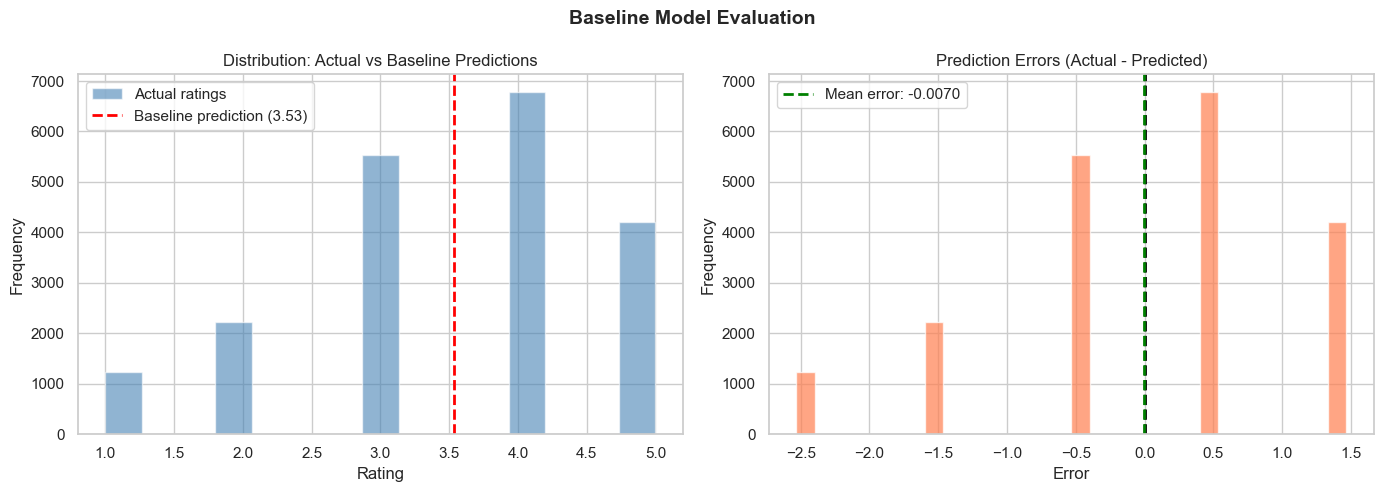

Error statistics:
  Mean error:        -0.0070 (should be ~0)
  Median error:      0.4687
  Std dev of errors: 1.1238


In [12]:
# Visualization: Baseline predictions vs actual ratings

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of actual vs predicted
axes[0].hist(
    y_test,
    bins=15,
    alpha=0.6,
    label="Actual ratings",
    color="steelblue",
    edgecolor="white",
)
axes[0].axvline(
    global_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Baseline prediction ({global_mean:.2f})",
)
axes[0].set_title("Distribution: Actual vs Baseline Predictions")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].set_ylim(0, None)

# Errors
errors = y_test - y_baseline_pred
axes[1].hist(errors, bins=30, color="coral", edgecolor="white", alpha=0.7)
axes[1].axvline(0, color="black", linestyle="--", linewidth=2)
axes[1].set_title("Prediction Errors (Actual - Predicted)")
axes[1].set_xlabel("Error")
axes[1].set_ylabel("Frequency")
axes[1].axvline(
    errors.mean(),
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Mean error: {errors.mean():.4f}",
)
axes[1].legend()

plt.suptitle("Baseline Model Evaluation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/08_baseline_evaluation.png", bbox_inches="tight")
plt.show()

print(f"Error statistics:")
print(f"  Mean error:        {errors.mean():.4f} (should be ~0)")
print(f"  Median error:      {np.median(errors):.4f}")
print(f"  Std dev of errors: {errors.std():.4f}")

### Interpretación del Baseline

**RMSE = 1.1253:** En promedio, las predicciones del baseline se desvían del rating real en ±1.13 puntos 
en la escala 1–5. Esto significa que si el usuario califica una película con 4 estrellas, el baseline 
(que siempre predice 3.53) errará en aproximadamente 1.13 puntos de media.

**MAE = 0.9008:** El error promedio sin considerar dirección es de 0.90 puntos. Este valor más bajo que RMSE 
indica que hay pocas predicciones extremadamente erróneas — la mayoría de errores se concentra en una 
banda moderada alrededor de la media.

**Referencia para futuras iteraciones:** Cualquier modelo entrenado debe superar estos números para 
justificar su complejidad. En la Entrega 2, esperamos que modelos como **User-based CF** o **Item-based CF** 
reduzcan estos errores capturando patrones específicos de usuarios y películas.